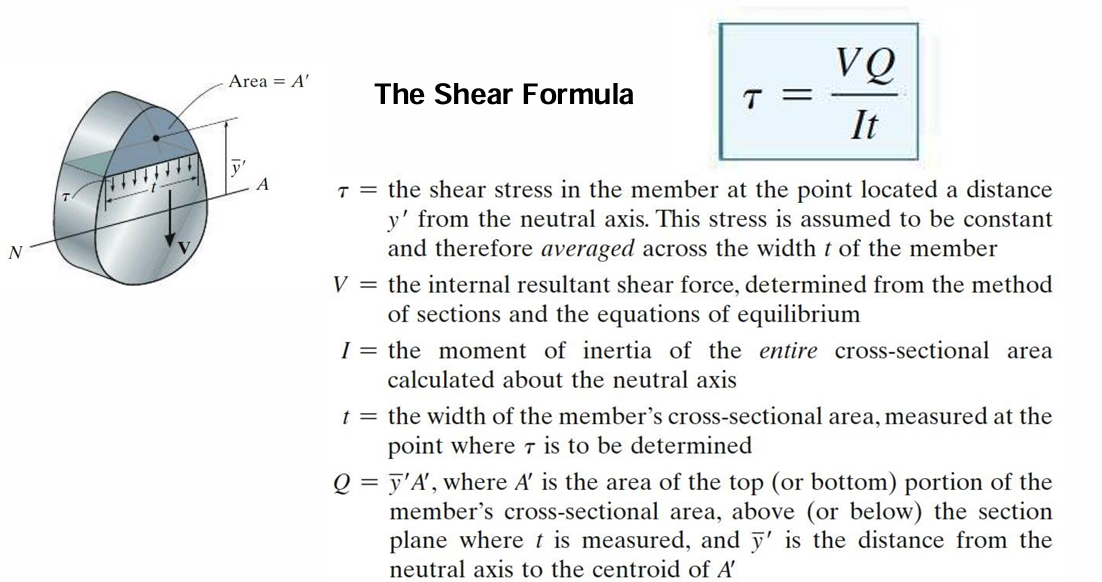

In [2]:
# 7.1
import numpy as np

b = 0.022 # m
t = 0.009 # m
Vy = 35000 # N

y = 0

Ic = (4*b+2*t)*(6*t+4*b)**3/12
Ie1 = 2*t*t**3/12 + 2*t*t*(2*b+2*t+t/2)**2
Ie2 = (2*t+2*b)*(2*b)**3/12 + 2*b*(2*t+2*b)*(b+2*t)**2
I = Ic - 2*Ie1 - 2*Ie2

T = 2*b

Aup = 2*(2*b*b)+2*t*2*b
y1 = 2*t+(t+2*b)/2
A1 = (2*b+t)*(4*b+2*t)
y2 = 2*t+b
A2 = 2*b*(2*b+2*t)
y3 = 2*b+2*t+t/2
A3 = 2*t*t
y_prime = (y1*A1-y2*A2-y3*A3)/(Aup)
Q = y_prime*Aup

tau = Vy*Q/(I*T)
print(tau/10**6)

7.26405762489168


In [3]:
# 7.2
import numpy as np

t1 = 0.007 # mm
t2 = 0.005 # mm
b = 0.078 # mm
h = 0.075 # mm
ybar = 48.33333/1000 # mm
Iz = 948000.00000/10**12 # mm^4
Vy = 26000 # kN
Mz = 616 # N.m

# sigma_max = Mz*(h+t2-ybar)/Iz
sigma_max = Mz*(ybar)/Iz
print(sigma_max/10**6)

T = 2*t1
# 最大剪应力出现在中性轴处。但是为什么呢
# 以A为到下边缘为例
A = 2*t1*ybar
yprime = ybar/2
Q = yprime*A

tau = Vy*Q/(Iz*T)
print(tau/10**6)

31.406467594936707
32.03527453117689


In [4]:
# 7.3 题型一
from sympy import *

b = 0.057 # mm
a = 0.713 # mm
P = 15000 # kN
sigmaAll = 198*10**6 # MPa
tauAll = 71*10**6 # MPa

h = symbols('h')
ybar = h/2
# 有多种题型
# 分析图可以得到最大的M和V
M = P*a
V = P
I = b*h**3/12

yprime = ybar/2
A = ybar*b
t = b
Q = A*yprime

sigma = M*ybar/I
tau = V*Q/(I*t)

eq1 = Eq(sigma,sigmaAll)
ans1 = solve(eq1,h)
print(ans1)

eq2 = Eq(tau,tauAll)
ans2 = solve(eq2,h)
print(ans2)
# 记得最后转换单位要乘以1000
# 两个答案中更大的那一个作为h的最小值
# 因为h要同时承担两个allow，太小了另一个会爆炸

[-0.0754042798695639, 0.0754042798695639]
[0.00555967383246849]


In [5]:
# 7.3 题型二
from sympy import *

b = 53/1000 # mm
a = 772/1000 # mm
P = 10*10**3 # kN
sigmaAll = 104*10**6 # MPa
tauAll = 72*10**6 # MPa

h = symbols('h')

I = b*h**3/12
M = P/2*a
sigma = M*h/2/I
ans1 = solve(sigmaAll - sigma,h)

V = P/2
Q = h/4*h*b/2
t = b
tau = V*Q/(I*t)
ans2 = solve(tauAll - tau, h)
print(ans1,ans2)

[-0.0648208427480841, 0.0648208427480841] [0.00196540880503144]


In [6]:
# 7.4
from sympy import *

h = 3 # in
a = 36 # in
P = 5*1000 # kips
s1 = 273 # psi
s2 = 234 # psi

b = symbols('b')

V = P
Qw = 1.5*h*b*0.75*h
t = b
I = b*(3*h)**3/12
tauw = V*Qw/(t*I)
answ = solve(tauw - s1,b)

Qg = h*b*h
taug = V*Qg/(t*I)
ansg = solve(taug - s2,b)

print(answ,ansg)
10000/3159

[3.05250305250305] [10000/3159]


3.1655587211142766

In [7]:
# 7.5 shear必须和中性轴垂直
import numpy as np

b = 34 # mm
V = 8 # kN

b = b/1000
V = V*1000

y1 = 3.5*b
A1 = 3*b*b
y2 = 2*b
A2 = b*2*b
y3 = 0.5*b
A3 = A1

ybar = 2*b

I1y = 3*b*b**3/12 + A1*(y1-ybar)**2
I2y = b*(2*b)**3/12 + A2*(y2-ybar)**2
I3y = 3*b*b**3/12 + A3*(y3-ybar)**2

Iy = I1y + I2y + I3y

ty = b
Qy = (y1-ybar)*b**2
tauy = V*Qy/(Iy*ty)

print(tauy/10**6)

0.7077697389116072


In [14]:
# 7.6
from sympy import *

h = 173 # mm
t = 41 # mm
d = 14 # mm
taub = 4 # MPa
V = 4 # kN

h = h/1000
t = t/1000
d = d/1000
taub = taub*10**6
V = V*1000

y1 = h/2
y2 = h
A1 = h*t

ybar = (y1*A1+y2*A1+y1*A1)/(A1*3)

I1 = t*h**3/12 + A1*(ybar-y1)**2
I2 = t*h**3/12 + A1*(ybar-y2)**2
I = I1+I2+I1

T = h/2
Q = A1*(ybar-y1)
q = V*Q/I #剪力流的表达公式，q
# 这意味着，交接面上每前进 1 毫米，就会积累q这么多的破坏力（让木板错位的力）。

Vbolt = taub*np.pi*(d/2)**2 #螺栓在一个剪切面上的力量 = taub*螺栓横截面积

ds = Vbolt/q
print(ds*1000) #每隔ds就要打一个螺栓，为了保证安全

66.57820231120172


In [10]:
# 7.7
import numpy as np

b = 220 # mm
t = 39 # mm
d = 13 # mm
deltaS = 98 # mm
Vy = 2 # kN

b = b/1000
t = t/1000
d = d/1000
deltaS = deltaS/1000
Vy = Vy*1000

ybar = t + b/2
Iout = b*(2*t+b)**3/12
Iin = (b-2*t)*b**3/12
I = Iout - Iin

#孤立上面的板作为分析
A = t*b
yprime = b+t+t/2-ybar
Q = A*yprime

q = Vy*Q/I

Vbolt = q*deltaS/2 #两个螺栓共同承担的力，一个螺栓除2

taubolt = Vbolt/(np.pi*(d/2)**2)
print(taubolt/10**6)

2.2840895011384093


In [ ]:
# 7.8
import numpy as np

D = 195 # mm
d = 105 # mm
V = 60 # kN

D = D/1000
d = d/1000
V = V*1000

I = np.pi/64*(D**4-d**4)

Q = (D**3-d**3)/12
# 对于半个空心圆环，其关于底边的面积矩等于实心大半圆的面积矩减去实心小半圆的面积矩。

t = D - d
tau = V*Q/(I*t)


print(I*10**12/10**6,Q*10**9/10**3,tau/10**6)

65.00887860596319 521.4375000000001 5.347346507960111


In [12]:
# 7.9
import numpy as np

b = 31 # in
t = 4 # in
d = 0.61 # in
deltaS = 45 # in
Vmax = 4 # lb

I1 = b*t**3/12 + t*b*((b+t)/2)**2
I2 = t*b**3/12
I = 2*I1+I2

Q1 = t*b*(b+t)/2
V1 = Vmax*I/(Q1*deltaS)

A = (b-t)/2*t
Q2 = A*(b+t)/2
V2 = Vmax*I/(Q2*deltaS)

print(I/1000,V1,V2)

86.211 3.5314285714285716 8.10920634920635
